# 01 — Faces vs objects validation GLM

This notebook runs a streamlined validation analysis using explicit human/object labels in the image filenames.

The goal is not to answer the main memory question, but to confirm that the fMRI pipeline can recover a plausible visual-category effect.

We estimate one two-run first-level GLM per subject:

- run 1 = PRE viewing (`ses-01`)
- run 2 = POST viewing (`ses-05`)

New images are modelled as `other` regressors and receive zero weight in the faces-vs-objects contrasts.


In [1]:
# ============================================================
# 1. Setup
# ============================================================

from pathlib import Path
from nilearn.image import load_img, resample_to_img
import sys
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display

pd.set_option("display.max_columns", 140)
pd.set_option("display.max_colwidth", 140)

PROJECT_ROOT = Path("/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project")
SRC_DIR = PROJECT_ROOT / "src"

if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from island_glm.paths import ProjectPaths, make_analysis_dirs
from island_glm.common import load_common_inputs, get_pre_post_subjects
from island_glm.events import (
    save_faces_objects_subject_events,
    build_faces_objects_event_qc,
    make_faces_objects_events,
)
from island_glm.contrasts import (
    make_faces_objects_contrasts,
    contrast_specs_to_table,
    preview_contrast_vectors,
)
from island_glm.first_level import run_faces_objects_first_level_subject
from island_glm.second_level import (
    verify_first_level_maps,
    run_second_level_all_contrasts,
    threshold_group_maps,
    make_cluster_tables,
)
from island_glm.reporting import label_cluster_table
from island_glm.plotting import plot_group_stat_map, make_interactive_view

ANALYSIS_NAME = "faces_objects_pre_post_viewing_glm"
SMOOTHING_FWHM = 5.0
SMOOTHING_LABEL = "smoothed5mm"
TEST_SUBJECT = "sub-P15"

# ------------------------------------------------------------
# Runtime flags
# ------------------------------------------------------------

RUN_FIRST_LEVEL = False
OVERWRITE_FIRST_LEVEL = False

RUN_SECOND_LEVEL = True
OVERWRITE_SECOND_LEVEL = True

USE_MEAN_T1W_BACKGROUND = True



paths = ProjectPaths.from_root(PROJECT_ROOT)
dirs = make_analysis_dirs(paths, ANALYSIS_NAME, smoothing_label=SMOOTHING_LABEL)

print("Project root:", paths.project_root)
print("Analysis output:", dirs["out"])


Project root: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project
Analysis output: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm


## Load common inputs from Notebook 00

Notebook 00 defines the final pre/post subject list and the common viewing item-label table. Here we reuse these stable inputs instead of reparsing subjects or filenames.

In [2]:
# ============================================================
# 2. Load common inputs
# ============================================================

manifest, subject_table, viewing_item_labels = load_common_inputs(paths)
subjects = get_pre_post_subjects(manifest, no_high_motion=False)
sensitivity_subjects = get_pre_post_subjects(manifest, no_high_motion=True)

sessions = manifest["sessions"]

print("Main sample N:", len(subjects))
print("Sensitivity no-high-motion N:", len(sensitivity_subjects))
print("Sessions:", sessions)

display(subject_table)
display(viewing_item_labels.head())

# ------------------------------------------------------------
# Load mean anatomical background from Notebook 00
# ------------------------------------------------------------

if USE_MEAN_T1W_BACKGROUND:
    mean_t1w_path = Path(manifest["mean_anat"]["mean_t1w_path"])
    mean_t1w_img = load_img(str(mean_t1w_path))

    print("\nLoaded mean T1w anatomical background:")
    print(mean_t1w_path)
    print("Shape:", mean_t1w_img.shape)
else:
    mean_t1w_path = None
    mean_t1w_img = None

Main sample N: 27
Sensitivity no-high-motion N: 25
Sessions: {'pre': 'ses-01', 'post': 'ses-05', 'task': 'viewing', 'run': '01', 'bold_space': 'MNI152NLin2009cAsym'}


,subject,included_primary_post_only,included_pre_post_N27,included_pre_post_no_high_motion_N25,excluded_from_pre_post,high_motion_flag,exclusion_reason
0,sub-P10,True,True,True,False,False,NaN
1,sub-P12,True,True,True,False,False,NaN
2,sub-P13,True,True,True,False,False,NaN
3,sub-P14,True,True,True,False,False,NaN
4,sub-P15,True,True,True,False,False,NaN
5,sub-P16,True,True,True,False,False,NaN
6,sub-P17,True,True,True,False,False,NaN
7,sub-P18,True,True,True,False,False,NaN
8,sub-P19,True,True,False,False,True,High-motion sensitivity exclusion.
9,sub-P21,True,True,False,False,True,High-motion sensitivity exclusion.


,subject,session,run,onset,duration,image_file,source_image_column,phase,theme,item_id,episode,episode_number,checkpoint_index,checkpoint_index_out_of,checkpoint_third,relevance_from_filename,object_category_from_filename,old_new,stimulus_version,relevance_condition,spatial_accuracy_z,spatial_accuracy_condition_centered,relevance,encoding_phase_third
0,sub-P10,ses-01,1,4.634,3.017,maya_3_e3_6_r_h_v1_old,event,pre,maya,3.0,e3,3.0,6.0,16,middle,relevant,human,old,1.0,NaN,NaN,NaN,relevant,middle
1,sub-P10,ses-01,1,11.701,3.017,wealth_5_e3_7_nr_o_v1_old,event,pre,wealth,5.0,e3,3.0,7.0,16,middle,irrelevant,object,old,1.0,NaN,NaN,NaN,irrelevant,middle
2,sub-P10,ses-01,1,17.934,3.017,pirate_6_e2_13_r_h_v1_old,event,pre,pirate,6.0,e2,2.0,13.0,16,late,relevant,human,old,1.0,NaN,NaN,NaN,relevant,late
3,sub-P10,ses-01,1,24.534,3.017,viking_11_new,event,pre,NaN,NaN,NaN,NaN,NaN,16,NaN,NaN,NaN,new,NaN,NaN,NaN,NaN,NaN,NaN
4,sub-P10,ses-01,1,30.451,3.016,pirate_7_e3_1_nr_h_v1_old,event,pre,pirate,7.0,e3,3.0,1.0,16,early,irrelevant,human,old,1.0,NaN,NaN,NaN,irrelevant,early



Loaded mean T1w anatomical background:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/common_inputs/mean_anat/mean_T1w_prepost_N27_subjects_MNI152NLin2009cAsym.nii.gz
Shape: (193, 229, 193)


## Design

For each subject, we model PRE and POST viewing as two runs. The task regressors are:

$$
\beta_{\mathrm{pre,face}},\quad
\beta_{\mathrm{pre,object}},\quad
\beta_{\mathrm{pre,other}},\quad
\beta_{\mathrm{post,face}},\quad
\beta_{\mathrm{post,object}},\quad
\beta_{\mathrm{post,other}}.
$$

Old images with filename token `h` are labelled as `face`; old images with filename token `o` are labelled as `object`. New images do not carry the `h/o` manipulation and are therefore modelled as `other`.

The first-level model is:

$$
Y(t) = X_{\mathrm{task}}(t)\beta_{\mathrm{task}} + X_{\mathrm{confounds}}(t)\beta_{\mathrm{confounds}} + \epsilon(t).
$$

Confounds are loaded from fMRIPrep: motion, white matter, CSF, and high-pass cosine regressors.

## Contrasts

We estimate face-object effects separately for PRE and POST, then combine them and test whether the face-object effect changes from PRE to POST.

Pre-viewing validation:

$$
C_{\mathrm{pre,face>object}} = \beta_{\mathrm{pre,face}} - \beta_{\mathrm{pre,object}}.
$$

Post-viewing validation:

$$
C_{\mathrm{post,face>object}} = \beta_{\mathrm{post,face}} - \beta_{\mathrm{post,object}}.
$$

Average across PRE and POST:

$$
C_{\mathrm{both,face>object}} =

\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})
-
\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}}).
$$

POST-vs-PRE interaction:

$$
C_{\mathrm{post>pre,face>object}} =
(\beta_{\mathrm{post,face}}-\beta_{\mathrm{post,object}})
-
(\beta_{\mathrm{pre,face}}-\beta_{\mathrm{pre,object}}).
$$

In [3]:
# ============================================================
# 3. Define contrasts and save contrast table
# ============================================================

contrast_specs = make_faces_objects_contrasts()
contrast_table = contrast_specs_to_table(contrast_specs)

contrast_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_contrast_definitions.csv"
contrast_table.to_csv(contrast_table_path, index=False)

display(contrast_table)
print("Saved:", contrast_table_path)


,contrast,priority,formula,interpretation,pre_face,pre_object,post_face,post_object
0,pre_faces_gt_objects,pre_validation,"$$\beta_{\mathrm{pre,face}}-\beta_{\mathrm{pre,object}}$$",Pre-viewing face > object validation contrast.,1.0,-1.0,0.0,0.0
1,post_faces_gt_objects,post_validation,"$$\beta_{\mathrm{post,face}}-\beta_{\mathrm{post,object}}$$",Post-viewing face > object validation contrast.,0.0,0.0,1.0,-1.0
2,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",Average face > object effect across PRE and POST viewing.,0.5,-0.5,0.5,-0.5
3,faces_gt_objects_post_gt_pre,post_pre_interaction,"$$(\beta_{\mathrm{post,face}}-\beta_{\mathrm{post,object}})-(\beta_{\mathrm{pre,face}}-\beta_{\mathrm{pre,object}})$$",Tests whether the face > object effect is stronger at POST than PRE.,-1.0,1.0,1.0,-1.0
4,objects_gt_faces_both,reverse_control,"$$\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})-\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})$$",Reverse validation control: average object > face effect across PRE and POST.,-0.5,0.5,-0.5,0.5


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/tables/faces_objects_pre_post_viewing_glm_contrast_definitions.csv


## Event relabelling

We build one clean event table per subject and phase. Each table has four BIDS-compatible GLM columns:

```text
onset, duration, trial_type, modulation
```

Expected per subject and phase: 144 face trials, 144 object trials, and 96 other/new trials.

In [4]:
# ============================================================
# 4. Create faces/object event files and event-count QC
# ============================================================

for subject in subjects:
    save_faces_objects_subject_events(
        viewing_item_labels=viewing_item_labels,
        subject=subject,
        events_dir=dirs["events"],
    )

event_qc, all_events_long = build_faces_objects_event_qc(
    viewing_item_labels=viewing_item_labels,
    subjects=subjects,
    events_dir=dirs["events"],
)

event_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_event_count_qc.csv"
all_events_path = dirs["events"] / f"all_subjects_{ANALYSIS_NAME}_events_long.tsv"

event_qc.to_csv(event_qc_path, index=False)
all_events_long.to_csv(all_events_path, sep="\t", index=False)

print("Saved event QC:", event_qc_path)
print("Saved all events:", all_events_path)

print("\nEvent counts by phase and trial type:")
display(
    all_events_long
    .groupby(["phase", "trial_type"])
    .size()
    .reset_index(name="n_rows")
)

print("\nSubject-level QC:")
display(event_qc.head())

# Strict checks for the clean N=27 pre/post viewing sample.
assert len(event_qc) == len(subjects) * 2
assert (event_qc["n_events"] == 384).all()
assert (event_qc["n_face"] == 144).all()
assert (event_qc["n_object"] == 144).all()
assert (event_qc["n_other"] == 96).all()

print("Event relabelling checks passed.")


Saved event QC: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/tables/faces_objects_pre_post_viewing_glm_event_count_qc.csv
Saved all events: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_faces_objects_pre_post_viewing_glm/all_subjects_faces_objects_pre_post_viewing_glm_events_long.tsv

Event counts by phase and trial type:


,phase,trial_type,n_rows
0,post,post_face,3888
1,post,post_object,3888
2,post,post_other,2592
3,pre,pre_face,3888
4,pre,pre_object,3888
5,pre,pre_other,2592



Subject-level QC:


,subject,phase,n_events,n_face,n_object,n_other,events_path
0,sub-P10,pre,384,144,144,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_faces_objects_pre_post_viewing_glm/...
1,sub-P10,post,384,144,144,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_faces_objects_pre_post_viewing_glm/...
2,sub-P12,pre,384,144,144,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_faces_objects_pre_post_viewing_glm/...
3,sub-P12,post,384,144,144,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_faces_objects_pre_post_viewing_glm/...
4,sub-P13,pre,384,144,144,96,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/preprocessed/relabeled_events_faces_objects_pre_post_viewing_glm/...


Event relabelling checks passed.


## Single-subject design-matrix preview

Before running all subjects, we fit one example subject and inspect the design matrix and contrast vectors. This is the key sanity check: PRE-specific regressors should appear only in run 1, and POST-specific regressors should appear only in run 2.

In [5]:
# ============================================================
# 5. Single-subject design preview
# ============================================================

subject_qc_preview, contrast_qc_preview = run_faces_objects_first_level_subject(
    subject=TEST_SUBJECT,
    paths=paths,
    viewing_item_labels=viewing_item_labels,
    contrast_specs=contrast_specs,
    output_dirs=dirs,
    sessions=sessions,
    smoothing_fwhm=SMOOTHING_FWHM,
    smoothing_label=SMOOTHING_LABEL,
    hrf_model="spm",
    save_outputs=False,
    make_design_plot=True,
)

preview_subject_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_design_preview_subject_qc.csv"
preview_contrast_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_{TEST_SUBJECT}_contrast_vector_preview_qc.csv"

subject_qc_preview.to_csv(preview_subject_qc_path, index=False)
contrast_qc_preview.to_csv(preview_contrast_qc_path, index=False)

print("Subject QC preview:")
display(subject_qc_preview)

print("Contrast-vector preview:")
display(contrast_qc_preview)

# Expected: no contrast should be null across both runs.
assert not contrast_qc_preview.groupby("contrast")["is_null_vector"].all().any()

print("Design and contrast-vector preview passed.")

[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.
[FirstLevelModel.fit] A 'modulation' column was found in the given events data and is used.


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/first_level.py:153: UserWarning: Contrast for run 1 is null.
  z_map = model.compute_contrast(run_vectors, output_type="z_score")
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/first_level.py:154: UserWarning: Contrast for run 1 is null.
  effect_map = model.compute_contrast(run_vectors, output_type="effect_size")
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/first_level.py:153: UserWarning: Contrast for run 0 is null.
  z_map = model.compute_contrast(run_vectors, output_type="z_score")
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/first_level.py:154: UserWarning: Contrast for run 0 is null.
  effect_map = model.compute_contrast(run_vectors, output_type="effect_size")


Subject QC preview:


,subject,tr,n_pre_scans,n_post_scans,n_pre_events,n_post_events,pre_event_types,post_event_types,n_pre_confounds,n_post_confounds,pre_sample_mask_originally_none,post_sample_mask_originally_none,sample_masks_passed_to_nilearn,n_design_columns_run_1,n_design_columns_run_2,design_columns_run_1,design_columns_run_2
0,sub-P15,1.3,1986,1995,384,384,pre_face;pre_object;pre_other,post_face;post_object;post_other,65,65,True,True,False,69,69,pre_face;pre_object;pre_other;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosine1...,post_face;post_object;post_other;cosine00;cosine01;cosine02;cosine03;cosine04;cosine05;cosine06;cosine07;cosine08;cosine09;cosine10;cosi...


Contrast-vector preview:


,subject,contrast,priority,run,n_design_columns,n_nonzero_weights,nonzero_regressors,nonzero_weights,missing_regressors_expected,is_null_vector
0,sub-P15,pre_faces_gt_objects,pre_validation,1,69,2,pre_face;pre_object,1.0;-1.0,,False
1,sub-P15,pre_faces_gt_objects,pre_validation,2,69,0,,,pre_face;pre_object,True
2,sub-P15,post_faces_gt_objects,post_validation,1,69,0,,,post_face;post_object,True
3,sub-P15,post_faces_gt_objects,post_validation,2,69,2,post_face;post_object,1.0;-1.0,,False
4,sub-P15,both_faces_gt_objects,combined_validation,1,69,2,pre_face;pre_object,0.5;-0.5,post_face;post_object,False
5,sub-P15,both_faces_gt_objects,combined_validation,2,69,2,post_face;post_object,0.5;-0.5,pre_face;pre_object,False
6,sub-P15,faces_gt_objects_post_gt_pre,post_pre_interaction,1,69,2,pre_face;pre_object,-1.0;1.0,post_face;post_object,False
7,sub-P15,faces_gt_objects_post_gt_pre,post_pre_interaction,2,69,2,post_face;post_object,1.0;-1.0,pre_face;pre_object,False
8,sub-P15,objects_gt_faces_both,reverse_control,1,69,2,pre_face;pre_object,-0.5;0.5,post_object;post_face,False
9,sub-P15,objects_gt_faces_both,reverse_control,2,69,2,post_face;post_object,-0.5;0.5,pre_object;pre_face,False


Design and contrast-vector preview passed.


## Run first-level GLMs

The first-level GLM is fit separately for each subject using two runs. Contrast maps are saved for later group-level analysis.

In [6]:
# ============================================================
# 6. Run or load first-level GLM results
# ============================================================

from island_glm.second_level import first_level_map_path

first_level_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_qc_{SMOOTHING_LABEL}.csv"
first_level_contrast_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_contrast_qc_{SMOOTHING_LABEL}.csv"
failed_subjects_path = dirs["tables"] / f"{ANALYSIS_NAME}_failed_subjects_{SMOOTHING_LABEL}.csv"

def subject_has_all_first_level_maps(subject, contrast_specs, dirs, smoothing_label):
    """Return True if all expected z and effect maps exist for one subject."""
    for contrast_name in contrast_specs.keys():
        z_path = first_level_map_path(
            dirs,
            subject,
            contrast_name,
            smoothing_label,
            map_type="z",
        )
        effect_path = first_level_map_path(
            dirs,
            subject,
            contrast_name,
            smoothing_label,
            map_type="effect",
        )
        if not z_path.exists() or not effect_path.exists():
            return False
    return True


existing_subjects = [
    subject
    for subject in subjects
    if subject_has_all_first_level_maps(
        subject,
        contrast_specs,
        dirs,
        SMOOTHING_LABEL,
    )
]

missing_subjects = [
    subject
    for subject in subjects
    if subject not in existing_subjects
]

print("Existing complete first-level subjects:", len(existing_subjects))
print("Missing/incomplete first-level subjects:", len(missing_subjects))

if len(missing_subjects) > 0:
    print("Missing/incomplete:", missing_subjects)

# ------------------------------------------------------------
# Run first-level if requested
# ------------------------------------------------------------

if RUN_FIRST_LEVEL:
    if OVERWRITE_FIRST_LEVEL:
        subjects_to_run = subjects
        print("\nOVERWRITE_FIRST_LEVEL=True, rerunning all subjects.")
    else:
        subjects_to_run = missing_subjects
        print("\nOVERWRITE_FIRST_LEVEL=False, running only missing/incomplete subjects.")

    first_level_qc_rows = []
    first_level_contrast_qc_rows = []
    failed_rows = []

    for subject in subjects_to_run:
        print("=" * 80)
        print("Running faces/objects first-level GLM:", subject)

        try:
            subject_qc, contrast_qc = run_faces_objects_first_level_subject(
                subject=subject,
                paths=paths,
                viewing_item_labels=viewing_item_labels,
                contrast_specs=contrast_specs,
                output_dirs=dirs,
                sessions=sessions,
                smoothing_fwhm=SMOOTHING_FWHM,
                smoothing_label=SMOOTHING_LABEL,
                hrf_model="spm",
                save_outputs=True,
                make_design_plot=False,
            )

            first_level_qc_rows.append(subject_qc)
            first_level_contrast_qc_rows.append(contrast_qc)

            print("Finished:", subject)

        except Exception as exc:
            failed_rows.append({
                "subject": subject,
                "error_type": type(exc).__name__,
                "error_message": str(exc),
            })
            print("FAILED:", subject, type(exc).__name__, str(exc))

    new_first_level_qc = (
        pd.concat(first_level_qc_rows, ignore_index=True)
        if first_level_qc_rows
        else pd.DataFrame()
    )

    new_first_level_contrast_qc = (
        pd.concat(first_level_contrast_qc_rows, ignore_index=True)
        if first_level_contrast_qc_rows
        else pd.DataFrame()
    )

    failed_subjects = pd.DataFrame(failed_rows)

    # --------------------------------------------------------
    # Merge with previous QC if we only ran missing subjects
    # --------------------------------------------------------

    if first_level_qc_path.exists() and not OVERWRITE_FIRST_LEVEL:
        old_first_level_qc = pd.read_csv(first_level_qc_path)
        first_level_qc = pd.concat(
            [old_first_level_qc, new_first_level_qc],
            ignore_index=True,
        )
        first_level_qc = first_level_qc.drop_duplicates(
            subset=["subject"],
            keep="last",
        )
    else:
        first_level_qc = new_first_level_qc

    if first_level_contrast_qc_path.exists() and not OVERWRITE_FIRST_LEVEL:
        old_first_level_contrast_qc = pd.read_csv(first_level_contrast_qc_path)
        first_level_contrast_qc = pd.concat(
            [old_first_level_contrast_qc, new_first_level_contrast_qc],
            ignore_index=True,
        )
        first_level_contrast_qc = first_level_contrast_qc.drop_duplicates(
            subset=["subject", "contrast", "run"],
            keep="last",
        )
    else:
        first_level_contrast_qc = new_first_level_contrast_qc

    first_level_qc.to_csv(first_level_qc_path, index=False)
    first_level_contrast_qc.to_csv(first_level_contrast_qc_path, index=False)
    failed_subjects.to_csv(failed_subjects_path, index=False)

else:
    print("\nRUN_FIRST_LEVEL=False, loading existing first-level QC tables.")

    assert first_level_qc_path.exists(), (
        f"Missing first-level QC table: {first_level_qc_path}. "
        "Set RUN_FIRST_LEVEL=True once to generate it."
    )

    assert first_level_contrast_qc_path.exists(), (
        f"Missing first-level contrast QC table: {first_level_contrast_qc_path}. "
        "Set RUN_FIRST_LEVEL=True once to generate it."
    )

    first_level_qc = pd.read_csv(first_level_qc_path)
    first_level_contrast_qc = pd.read_csv(first_level_contrast_qc_path)

    if failed_subjects_path.exists():
        failed_subjects = pd.read_csv(failed_subjects_path)
    else:
        failed_subjects = pd.DataFrame(
            columns=["subject", "error_type", "error_message"]
        )

# ------------------------------------------------------------
# Always verify maps after running or loading
# ------------------------------------------------------------

map_qc = verify_first_level_maps(
    subjects,
    contrast_specs,
    dirs,
    SMOOTHING_LABEL,
)

display(map_qc)

assert (map_qc["n_z_maps"] == len(subjects)).all(), (
    "Some first-level z-maps are missing. "
    "Set RUN_FIRST_LEVEL=True and OVERWRITE_FIRST_LEVEL=False to run only missing subjects."
)

assert (map_qc["n_effect_maps"] == len(subjects)).all(), (
    "Some first-level effect maps are missing. "
    "Set RUN_FIRST_LEVEL=True and OVERWRITE_FIRST_LEVEL=False to run only missing subjects."
)

print("\nFirst-level ready.")
print("Subjects in QC table:", first_level_qc["subject"].nunique())
print("Failed subjects:", len(failed_subjects))

display(first_level_qc)
display(failed_subjects)

assert len(failed_subjects) == 0, "Some subjects failed. Inspect failed_subjects."

Existing complete first-level subjects: 27
Missing/incomplete first-level subjects: 0

RUN_FIRST_LEVEL=False, loading existing first-level QC tables.


,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,pre_faces_gt_objects,pre_validation,27,27,27
1,post_faces_gt_objects,post_validation,27,27,27
2,both_faces_gt_objects,combined_validation,27,27,27
3,faces_gt_objects_post_gt_pre,post_pre_interaction,27,27,27
4,objects_gt_faces_both,reverse_control,27,27,27



First-level ready.
Subjects in QC table: 27
Failed subjects: 0


,subject,all_expected_first_level_maps_exist,recovered_from_saved_maps
0,sub-P10,True,True
1,sub-P12,True,True
2,sub-P13,True,True
3,sub-P14,True,True
4,sub-P15,True,True
5,sub-P16,True,True
6,sub-P17,True,True
7,sub-P18,True,True
8,sub-P19,True,True
9,sub-P21,True,True


,subject,error_type,error_message


## Verify first-level maps

Each contrast should have one z-map and one effect-size map per subject.

In [7]:
# ============================================================
# 7. Verify first-level maps
# ============================================================

map_qc = verify_first_level_maps(subjects, contrast_specs, dirs, SMOOTHING_LABEL)
map_qc_path = dirs["tables"] / f"{ANALYSIS_NAME}_first_level_map_qc_{SMOOTHING_LABEL}.csv"
map_qc.to_csv(map_qc_path, index=False)

display(map_qc)
print("Saved:", map_qc_path)

assert (map_qc["n_z_maps"] == len(subjects)).all()
assert (map_qc["n_effect_maps"] == len(subjects)).all()

,contrast,priority,n_subjects,n_z_maps,n_effect_maps
0,pre_faces_gt_objects,pre_validation,27,27,27
1,post_faces_gt_objects,post_validation,27,27,27
2,both_faces_gt_objects,combined_validation,27,27,27
3,faces_gt_objects_post_gt_pre,post_pre_interaction,27,27,27
4,objects_gt_faces_both,reverse_control,27,27,27


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/tables/faces_objects_pre_post_viewing_glm_first_level_map_qc_smoothed5mm.csv


## Second-level GLM

At the group level, each first-level effect map enters a one-sample test against zero. This tests whether the subject-level contrast is consistently positive across participants.

In [8]:
# ============================================================
# 8. Run or load second-level GLM
# ============================================================

second_level_table_path = dirs["tables"] / f"{ANALYSIS_NAME}_second_level_maps_{SMOOTHING_LABEL}.csv"

if RUN_SECOND_LEVEL:
    if second_level_table_path.exists() and not OVERWRITE_SECOND_LEVEL:
        print("RUN_SECOND_LEVEL=True but existing second-level table found.")
        print("OVERWRITE_SECOND_LEVEL=False, loading existing second-level maps.")

        second_level_table = pd.read_csv(second_level_table_path)

    else:
        print("Running second-level GLM.")

        second_level_table = run_second_level_all_contrasts(
            subjects=subjects,
            contrast_specs=contrast_specs,
            output_dirs=dirs,
            smoothing_label=SMOOTHING_LABEL,
        )

        second_level_table.to_csv(second_level_table_path, index=False)

else:
    print("RUN_SECOND_LEVEL=False, loading existing second-level table.")

    assert second_level_table_path.exists(), (
        f"Missing second-level table: {second_level_table_path}. "
        "Set RUN_SECOND_LEVEL=True once to generate it."
    )

    second_level_table = pd.read_csv(second_level_table_path)

display(second_level_table)
print("Second-level table:", second_level_table_path)

assert second_level_table["z_map_exists"].all()
assert second_level_table["effect_map_exists"].all()

Running second-level GLM.


,contrast,priority,formula,n_subjects,z_map_path,effect_map_path,z_map_exists,effect_map_exists
0,pre_faces_gt_objects,pre_validation,"$$\beta_{\mathrm{pre,face}}-\beta_{\mathrm{pre,object}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...,True,True
1,post_faces_gt_objects,post_validation,"$$\beta_{\mathrm{post,face}}-\beta_{\mathrm{post,object}}$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...,True,True
2,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...,True,True
3,faces_gt_objects_post_gt_pre,post_pre_interaction,"$$(\beta_{\mathrm{post,face}}-\beta_{\mathrm{post,object}})-(\beta_{\mathrm{pre,face}}-\beta_{\mathrm{pre,object}})$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...,True,True
4,objects_gt_faces_both,reverse_control,"$$\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})-\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})$$",27,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...,True,True


Second-level table: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/tables/faces_objects_pre_post_viewing_glm_second_level_maps_smoothed5mm.csv


## Thresholding and cluster tables

We save both corrected threshold summaries and exploratory cluster tables. The primary validation threshold for visualization is exploratory unless corrected maps survive FDR/Bonferroni.

In [9]:
# ============================================================
# 9. Threshold maps and create cluster tables
# ============================================================

threshold_summary = threshold_group_maps(second_level_table, dirs)
threshold_summary_path = dirs["tables"] / f"{ANALYSIS_NAME}_threshold_summary_{SMOOTHING_LABEL}.csv"
threshold_summary.to_csv(threshold_summary_path, index=False)

cluster_summary, cluster_details = make_cluster_tables(
    second_level_table=second_level_table,
    output_dirs=dirs,
    thresholds=(2.33, 3.0),
    cluster_threshold_voxels=10,
)

cluster_summary_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_summary_{SMOOTHING_LABEL}.csv"
cluster_details_path = dirs["tables"] / f"{ANALYSIS_NAME}_cluster_details_{SMOOTHING_LABEL}.csv"
cluster_summary.to_csv(cluster_summary_path, index=False)
cluster_details.to_csv(cluster_details_path, index=False)

print("Threshold summary:")
display(threshold_summary.sort_values(["contrast", "threshold_label"]))

print("Cluster summary:")
display(cluster_summary)

print("Saved:")
print(threshold_summary_path)
print(cluster_summary_path)
print(cluster_details_path)


/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, z_threshold = threshold_stats_img(
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/src/island_glm/second_level.py:85: FutureWarning: 
From nilearn version>=0.15, the default 'threshold' will be set to 3.090232306167813.
  thresholded_img, z_thres

Threshold summary:


,contrast,priority,formula,threshold_label,height_control,alpha,two_sided,z_threshold,n_nonzero_voxels,max_z,thresholded_map_path
11,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,166,6.100041,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
9,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",fdr_q05_one_sided,fdr,0.050,False,3.167237,2002,6.100041,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
10,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",fdr_q10_one_sided,fdr,0.100,False,2.889613,2509,6.100041,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
8,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,2290,6.100041,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
15,faces_gt_objects_post_gt_pre,post_pre_interaction,"$$(\beta_{\mathrm{post,face}}-\beta_{\mathrm{post,object}})-(\beta_{\mathrm{pre,face}}-\beta_{\mathrm{pre,object}})$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
13,faces_gt_objects_post_gt_pre,post_pre_interaction,"$$(\beta_{\mathrm{post,face}}-\beta_{\mathrm{post,object}})-(\beta_{\mathrm{pre,face}}-\beta_{\mathrm{pre,object}})$$",fdr_q05_one_sided,fdr,0.050,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
14,faces_gt_objects_post_gt_pre,post_pre_interaction,"$$(\beta_{\mathrm{post,face}}-\beta_{\mathrm{post,object}})-(\beta_{\mathrm{pre,face}}-\beta_{\mathrm{pre,object}})$$",fdr_q10_one_sided,fdr,0.100,False,inf,0,NaN,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
12,faces_gt_objects_post_gt_pre,post_pre_interaction,"$$(\beta_{\mathrm{post,face}}-\beta_{\mathrm{post,object}})-(\beta_{\mathrm{pre,face}}-\beta_{\mathrm{pre,object}})$$",uncorrected_p001_one_sided,uncorrected,0.001,False,3.000000,349,4.357146,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
19,objects_gt_faces_both,reverse_control,"$$\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})-\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})$$",bonferroni_p05_one_sided,bonferroni,0.050,False,4.943085,104,5.974979,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
17,objects_gt_faces_both,reverse_control,"$$\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})-\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})$$",fdr_q05_one_sided,fdr,0.050,False,2.812486,6395,5.974979,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...


Cluster summary:


,contrast,priority,threshold_label,stat_threshold,cluster_threshold_voxels,n_clusters,max_peak_stat,largest_cluster_mm3,cluster_table_path
0,pre_faces_gt_objects,pre_validation,z_gt_2.33,2.33,10,24,5.982057,35640.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
1,pre_faces_gt_objects,pre_validation,z_gt_3.00,3.00,10,9,5.982057,12015.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
2,post_faces_gt_objects,post_validation,z_gt_2.33,2.33,10,22,6.108371,43437.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
3,post_faces_gt_objects,post_validation,z_gt_3.00,3.00,10,4,6.108371,28531.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
4,both_faces_gt_objects,combined_validation,z_gt_2.33,2.33,10,21,6.100041,44062.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
5,both_faces_gt_objects,combined_validation,z_gt_3.00,3.00,10,7,6.100041,28703.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
6,faces_gt_objects_post_gt_pre,post_pre_interaction,z_gt_2.33,2.33,10,43,4.357146,4171.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
7,faces_gt_objects_post_gt_pre,post_pre_interaction,z_gt_3.00,3.00,10,9,4.357146,734.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
8,objects_gt_faces_both,reverse_control,z_gt_2.33,2.33,10,42,5.974979,132953.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...
9,objects_gt_faces_both,reverse_control,z_gt_3.00,3.00,10,12,5.974979,68250.0,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/second_level_fro...


Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/tables/faces_objects_pre_post_viewing_glm_threshold_summary_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/tables/faces_objects_pre_post_viewing_glm_cluster_summary_smoothed5mm.csv
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/tables/faces_objects_pre_post_viewing_glm_cluster_details_smoothed5mm.csv


## Atlas labels for strongest exploratory peaks

This cell labels the top exploratory peaks using Harvard-Oxford. These labels are useful for reporting, but the exact anatomical interpretation should still be checked visually.

In [10]:
# ============================================================
# 10. Label strongest peaks for key contrasts
# ============================================================

key_contrasts = [
    "pre_faces_gt_objects",
    "post_faces_gt_objects",
    "both_faces_gt_objects",
    "faces_gt_objects_post_gt_pre",
]

key_clusters = (
    cluster_details
    .query("contrast in @key_contrasts and threshold_label == 'z_gt_2.33'")
    .sort_values(["contrast", "Peak Stat"], ascending=[True, False])
    .groupby("contrast")
    .head(10)
    .reset_index(drop=True)
)

# Use the first available group z-map as reference image for atlas resampling.
reference_img = second_level_table.iloc[0]["z_map_path"]
key_clusters_labeled = label_cluster_table(key_clusters, reference_img=reference_img)

key_clusters_labeled_path = dirs["tables"] / f"{ANALYSIS_NAME}_key_clusters_labeled_{SMOOTHING_LABEL}.csv"
key_clusters_labeled.to_csv(key_clusters_labeled_path, index=False)

display(key_clusters_labeled)
print("Saved:", key_clusters_labeled_path)


[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl
[fetch_atlas_harvard_oxford] Dataset found in /home/kroczak/nilearn_data/fsl


,Cluster ID,X,Y,Z,Peak Stat,Cluster Size (mm3),contrast,priority,formula,threshold_label,stat_threshold,cluster_threshold_voxels,harvard_oxford_cortical_label,harvard_oxford_cortical_value,harvard_oxford_subcortical_label,harvard_oxford_subcortical_value
0,1,41.5,-54.5,-18.0,6.100041,44062.0,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",z_gt_2.33,2.33,10,Temporal Occipital Fusiform Cortex,39,Right Cerebral Cortex,13
1,1a,14.0,-102.0,7.0,5.971982,NaN,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",z_gt_2.33,2.33,10,Occipital Pole,48,Right Cerebral Cortex,13
2,1b,26.5,-97.0,-10.5,5.796805,NaN,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",z_gt_2.33,2.33,10,Occipital Pole,48,Right Cerebral Cortex,13
3,1c,-11.0,-104.5,7.0,5.794383,NaN,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",z_gt_2.33,2.33,10,Occipital Pole,48,Left Cerebral Cortex,2
4,2,-18.5,-4.5,-15.5,5.381998,2953.0,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",z_gt_2.33,2.33,10,Background,0,Left Amygdala,10
5,3,16.5,-7.0,-18.0,5.279040,3578.0,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",z_gt_2.33,2.33,10,Background,0,Right Amygdala,20
6,3a,31.5,3.0,-28.0,4.162283,NaN,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",z_gt_2.33,2.33,10,Background,0,Right Cerebral White Matter,12
7,2a,-33.5,-7.0,-13.0,4.000974,NaN,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",z_gt_2.33,2.33,10,Background,0,Left Cerebral White Matter,1
8,4,44.0,-42.0,19.5,3.903588,687.0,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",z_gt_2.33,2.33,10,Background,0,Right Cerebral White Matter,12
9,5,-31.0,3.0,9.5,3.845227,281.0,both_faces_gt_objects,combined_validation,"$$\frac{1}{2}(\beta_{\mathrm{pre,face}}+\beta_{\mathrm{post,face}})-\frac{1}{2}(\beta_{\mathrm{pre,object}}+\beta_{\mathrm{post,object}})$$",z_gt_2.33,2.33,10,Background,0,Left Cerebral White Matter,1


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/tables/faces_objects_pre_post_viewing_glm_key_clusters_labeled_smoothed5mm.csv


## Static plots for slides / inspection

These plots center on the strongest exploratory peak for each key contrast, if available.

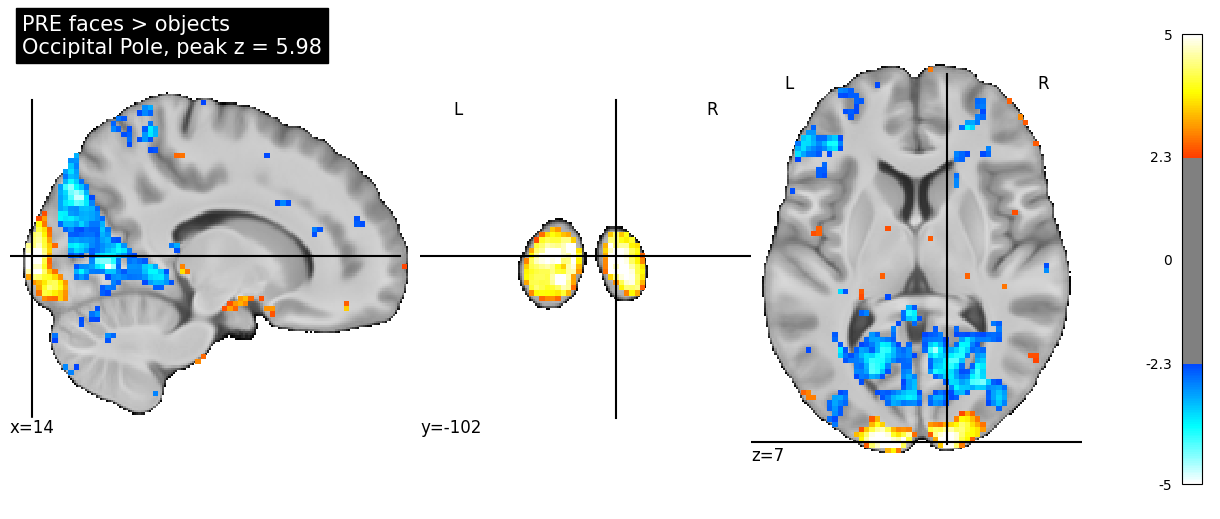

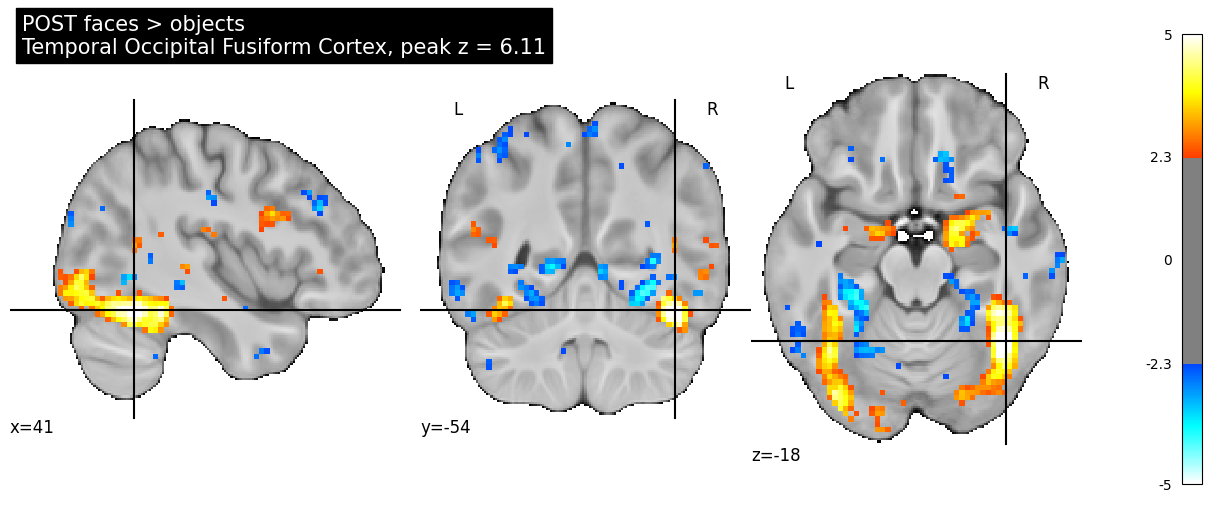

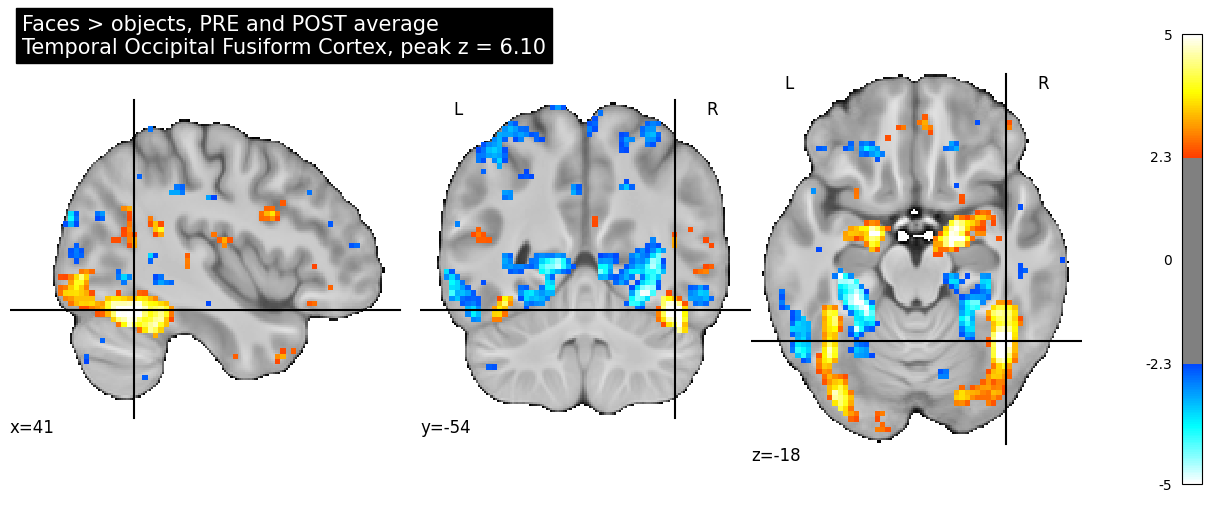

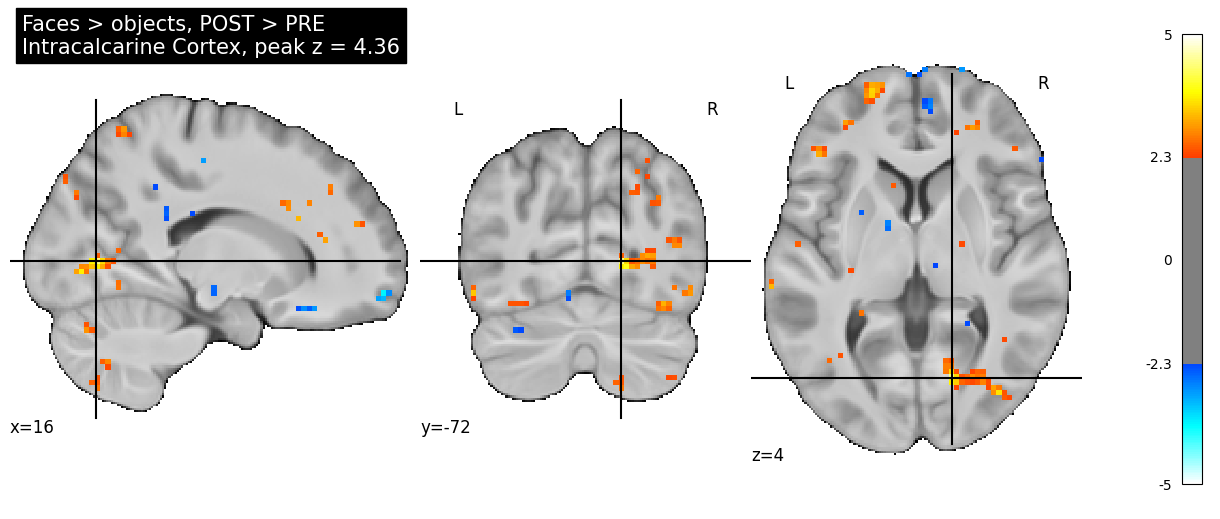

,contrast,figure_path,x,y,z,peak_z,atlas_label,background
0,pre_faces_gt_objects,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/figures/faces_ob...,14.0,-102.0,7.0,5.982057,Occipital Pole,mean_T1w
1,post_faces_gt_objects,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/figures/faces_ob...,41.5,-54.5,-18.0,6.108371,Temporal Occipital Fusiform Cortex,mean_T1w
2,both_faces_gt_objects,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/figures/faces_ob...,41.5,-54.5,-18.0,6.100041,Temporal Occipital Fusiform Cortex,mean_T1w
3,faces_gt_objects_post_gt_pre,/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/figures/faces_ob...,16.5,-72.0,4.5,4.357146,Intracalcarine Cortex,mean_T1w


Saved: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/tables/faces_objects_pre_post_viewing_glm_figure_index_on_mean_T1w_smoothed5mm.csv


In [11]:
# ============================================================
# 11. Plot strongest key contrasts on mean T1w background
# ============================================================

plot_index_rows = []

plot_title_map = {
    "pre_faces_gt_objects": "PRE faces > objects",
    "post_faces_gt_objects": "POST faces > objects",
    "both_faces_gt_objects": "Faces > objects, PRE and POST average",
    "faces_gt_objects_post_gt_pre": "Faces > objects, POST > PRE",
}

for contrast_name in key_contrasts:
    subset = key_clusters_labeled.query("contrast == @contrast_name").copy()

    if len(subset) == 0:
        print("No z > 2.33 clusters for", contrast_name)
        continue

    top = subset.sort_values("Peak Stat", ascending=False).iloc[0]

    z_map_path = second_level_table.set_index("contrast").loc[
        contrast_name,
        "z_map_path",
    ]

    cut_coords = (
        float(top["X"]),
        float(top["Y"]),
        float(top["Z"]),
    )

    atlas_label = top.get("harvard_oxford_cortical_label", "")

    if atlas_label == "Background":
        atlas_label = top.get("harvard_oxford_subcortical_label", "Background")

    title = (
        f"{plot_title_map[contrast_name]}\n"
        f"{atlas_label}, peak z = {float(top['Peak Stat']):.2f}"
    )

    fig_path = (
        dirs["figures"]
        / f"{ANALYSIS_NAME}_{contrast_name}_top_peak_on_mean_T1w_{SMOOTHING_LABEL}.png"
    )

    plot_group_stat_map(
        z_map_path=z_map_path,
        cut_coords=cut_coords,
        title=title,
        threshold=2.33,
        vmax=5.0,
        output_path=fig_path,
        bg_img=mean_t1w_img if USE_MEAN_T1W_BACKGROUND else None,
        dim=-0.2,
    )

    plot_index_rows.append({
        "contrast": contrast_name,
        "figure_path": str(fig_path),
        "x": cut_coords[0],
        "y": cut_coords[1],
        "z": cut_coords[2],
        "peak_z": float(top["Peak Stat"]),
        "atlas_label": atlas_label,
        "background": "mean_T1w" if USE_MEAN_T1W_BACKGROUND else "MNI_template",
    })

plot_index = pd.DataFrame(plot_index_rows)

plot_index_path = (
    dirs["tables"]
    / f"{ANALYSIS_NAME}_figure_index_on_mean_T1w_{SMOOTHING_LABEL}.csv"
)

plot_index.to_csv(plot_index_path, index=False)

display(plot_index)
print("Saved:", plot_index_path)

Selected coordinate: (-32.0, -54.0, -16.0)
Voxel index: (np.int64(18), np.int64(23), np.int64(24))
Approximate group z-value at coordinate: 2.910


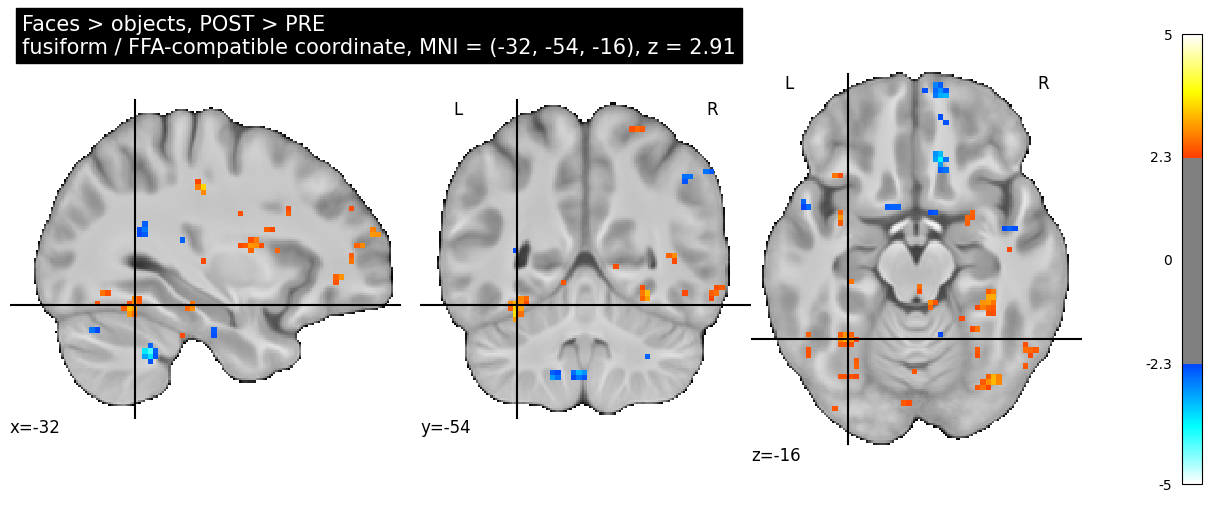

Saved:
/media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/figures/selected_validation_peaks/faces_objects_post_gt_pre_fusiform_FFA_coord_on_mean_T1w_smoothed5mm.png


In [12]:
# ============================================================
# Plot selected fusiform / FFA-compatible peak
# for faces > objects, POST > PRE interaction
# on mean T1w background
# ============================================================

import numpy as np
import matplotlib.pyplot as plt

from nilearn.image import load_img, resample_to_img
from nilearn.plotting import plot_stat_map

contrast_name = "faces_gt_objects_post_gt_pre"
selected_coord = (-32.0, -54.0, -16.0)

z_map_matches = second_level_table.loc[
    second_level_table["contrast"] == contrast_name,
    "z_map_path",
]

assert len(z_map_matches) == 1, (
    f"Expected exactly one z-map for {contrast_name}, "
    f"found {len(z_map_matches)}."
)

z_map_path = z_map_matches.iloc[0]
z_img = load_img(str(z_map_path))


voxel = np.round(
    np.linalg.inv(z_img.affine).dot(
        np.array([selected_coord[0], selected_coord[1], selected_coord[2], 1])
    )[:3]
).astype(int)

z_data = z_img.get_fdata()

if (
    0 <= voxel[0] < z_data.shape[0]
    and 0 <= voxel[1] < z_data.shape[1]
    and 0 <= voxel[2] < z_data.shape[2]
):
    selected_z = float(z_data[tuple(voxel)])
else:
    selected_z = np.nan

print("Selected coordinate:", selected_coord)
print("Voxel index:", tuple(voxel))
print(f"Approximate group z-value at coordinate: {selected_z:.3f}")

title = (
    "Faces > objects, POST > PRE\n"
    f"fusiform / FFA-compatible coordinate, "
    f"MNI = ({selected_coord[0]:.0f}, {selected_coord[1]:.0f}, {selected_coord[2]:.0f}), "
    f"z = {selected_z:.2f}"
)

fig = plt.figure(figsize=(12, 5))

display_obj = plot_stat_map(
    z_img,
    bg_img=mean_t1w_img,
    display_mode="ortho",
    cut_coords=selected_coord,
    threshold=2.33,
    vmax=5.0,
    cmap="cold_hot",
    black_bg=False,
    title=title,
    figure=fig,
    dim=-0.2,
)

selected_fig_dir = dirs["figures"] / "selected_validation_peaks"
selected_fig_dir.mkdir(parents=True, exist_ok=True)

selected_fig_path = (
    selected_fig_dir
    / f"faces_objects_post_gt_pre_fusiform_FFA_coord_on_mean_T1w_{SMOOTHING_LABEL}.png"
)

fig.savefig(selected_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:")
print(selected_fig_path)

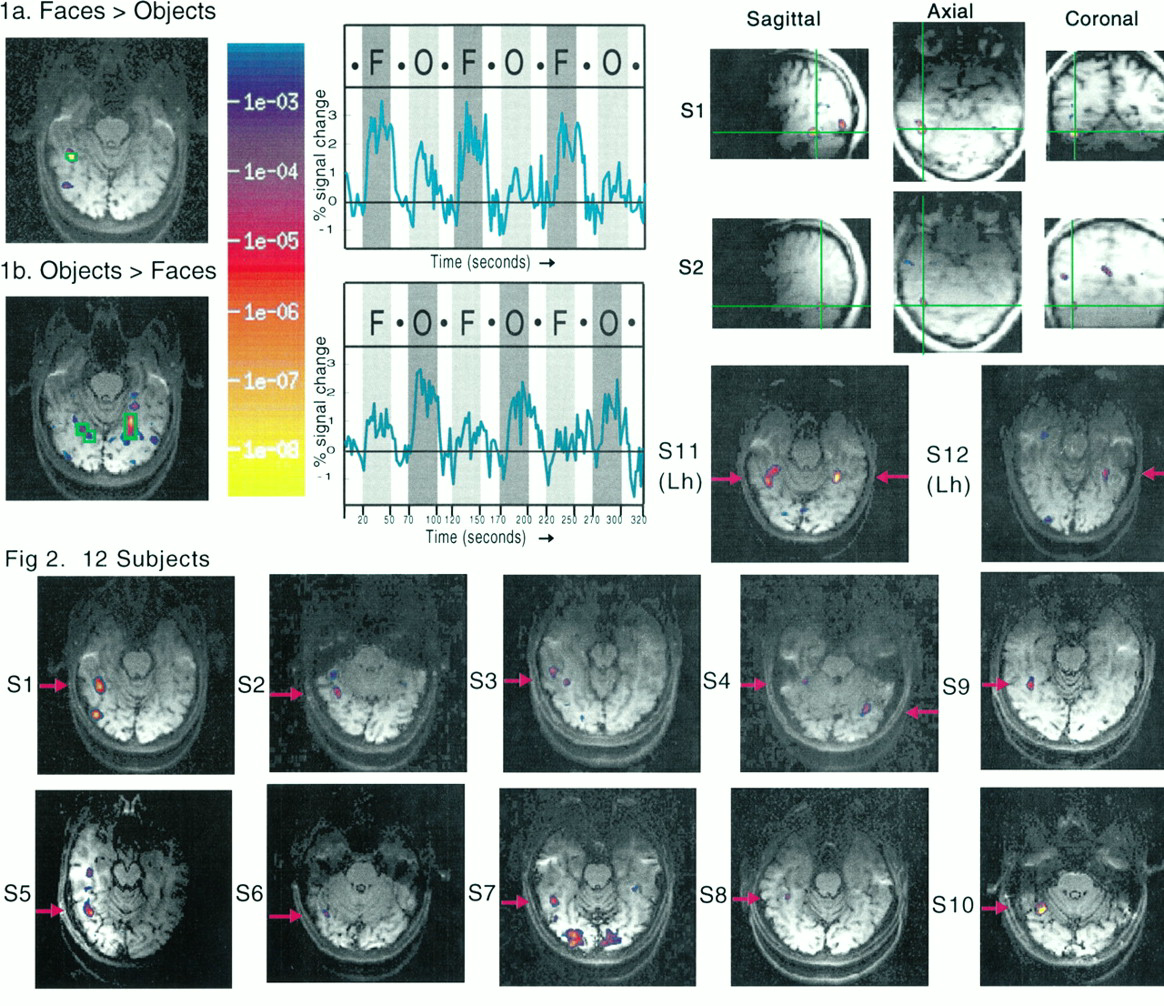

## Optional interactive views

Run one of the cells below when you want to inspect the map interactively.

/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



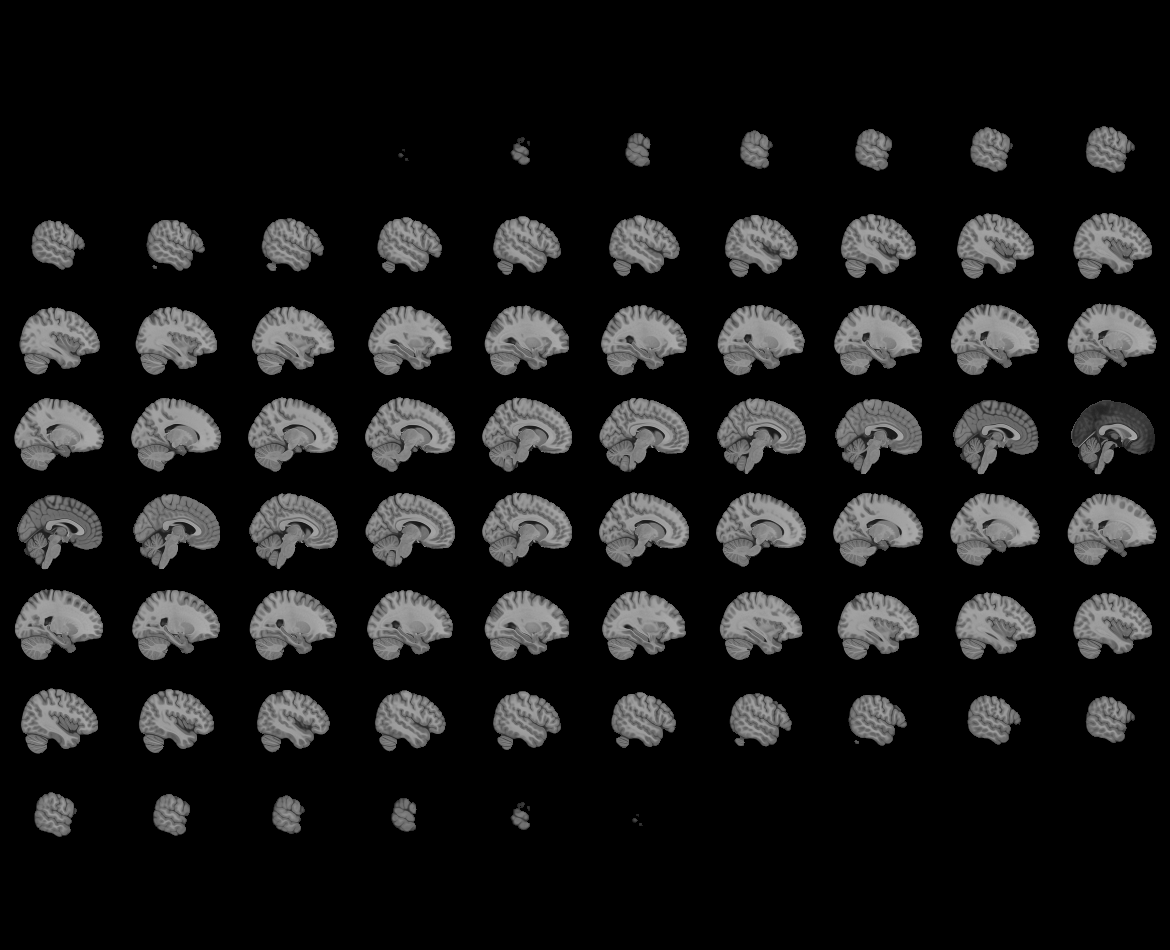
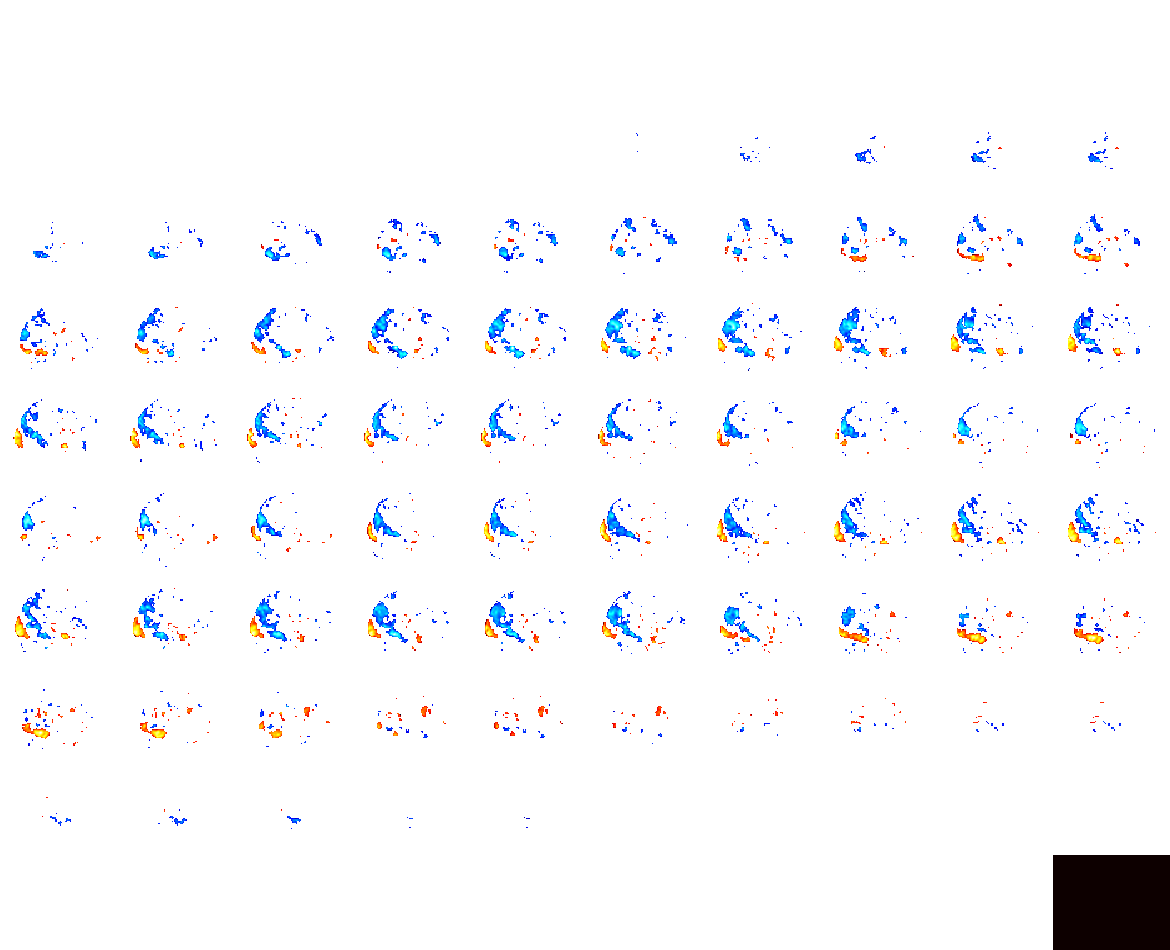

In [13]:
# Interactive view: combined PRE+POST faces > objects
contrast_name = "both_faces_gt_objects"
z_map_path = second_level_table.set_index("contrast").loc[contrast_name, "z_map_path"]
make_interactive_view(z_map_path, threshold=2.33, title="Faces > objects, PRE and POST average")


/home/kroczak/.conda/envs/island/lib/python3.10/site-packages/numpy/_core/fromnumeric.py:868: UserWarning: Warning: 'partition' will ignore the 'mask' of the MaskedArray.
  a.partition(kth, axis=axis, kind=kind, order=order)



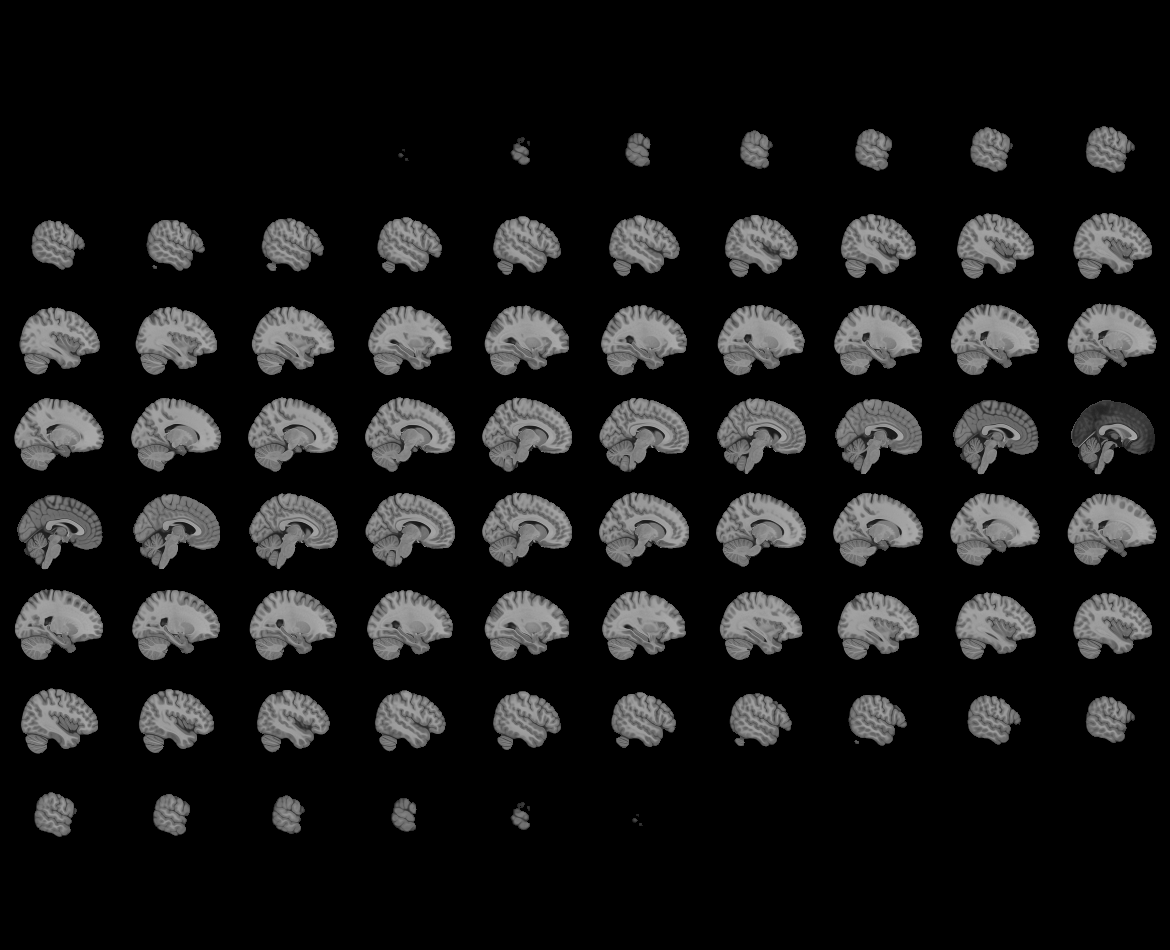
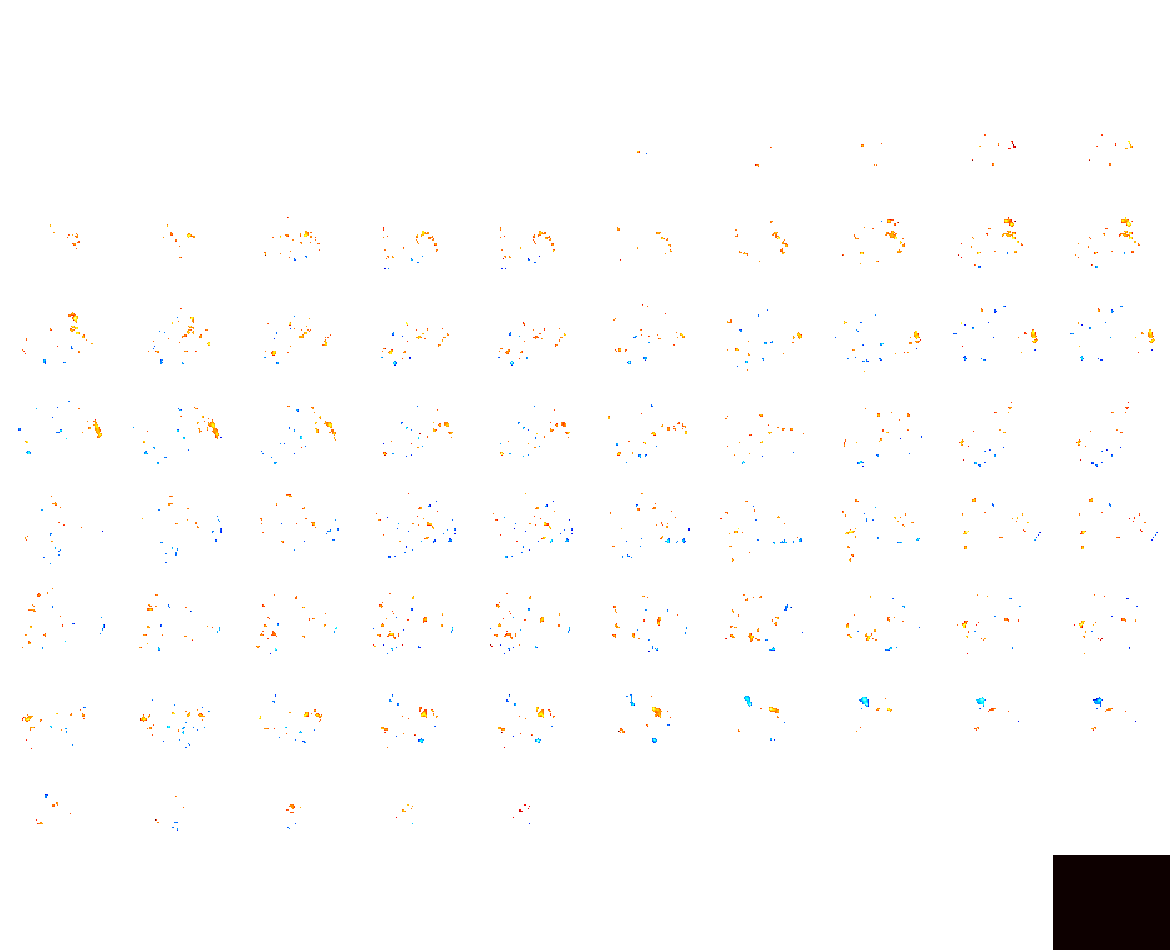

In [14]:
# Interactive view: POST > PRE change in the face-object effect
contrast_name = "faces_gt_objects_post_gt_pre"
z_map_path = second_level_table.set_index("contrast").loc[contrast_name, "z_map_path"]
make_interactive_view(z_map_path, threshold=2.33, title="Faces > objects, POST > PRE")


## Save restart manifest

Later summary notebooks can reload this analysis from the manifest instead of rerunning the GLM.

In [15]:
# ============================================================
# 12. Save restart manifest
# ============================================================

analysis_manifest = {
    "analysis_name": ANALYSIS_NAME,
    "project_root": str(PROJECT_ROOT),
    "smoothing_fwhm": SMOOTHING_FWHM,
    "smoothing_label": SMOOTHING_LABEL,
    "subjects": subjects,
    "sensitivity_subjects_no_high_motion": sensitivity_subjects,
    "sessions": sessions,
    "key_outputs": {
        "contrast_definitions": str(contrast_table_path),
        "event_qc": str(event_qc_path),
        "all_events": str(all_events_path),
        "first_level_qc": str(first_level_qc_path),
        "first_level_contrast_qc": str(first_level_contrast_qc_path),
        "first_level_map_qc": str(map_qc_path),
        "second_level_table": str(second_level_table_path),
        "threshold_summary": str(threshold_summary_path),
        "cluster_summary": str(cluster_summary_path),
        "cluster_details": str(cluster_details_path),
        "key_clusters_labeled": str(key_clusters_labeled_path),
        "figure_index": str(plot_index_path),
        "mean_t1w_background": str(mean_t1w_path),
    },
}

analysis_manifest_path = dirs["restart"] / f"{ANALYSIS_NAME}_restart_manifest.json"
with open(analysis_manifest_path, "w") as f:
    json.dump(analysis_manifest, f, indent=2)

print("Saved restart manifest:", analysis_manifest_path)


Saved restart manifest: /media/RCPNAS/Data3/Alison_island/kroczak/island_semester_project/data/processed/glm/faces_objects_pre_post_viewing_glm/restart/faces_objects_pre_post_viewing_glm_restart_manifest.json


1. All long first-level GLMs should save maps immediately.
2. Every notebook should have RUN_FIRST_LEVEL and OVERWRITE_FIRST_LEVEL flags.
3. Later cells should load/verify existing first-level maps instead of requiring reruns.
4. The common mean T1w background should be loaded from Notebook 00 manifest.
5. Plotting should use the same mean T1w background for cleaner figures.
6. src functions should be reusable; notebooks should mainly define the scientific question, call functions, and display results.